In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [3]:
df = pd.read_csv("AzureLLMInferenceTrace_code.csv")

print(df.head())
print(df.columns)

                     TIMESTAMP  ContextTokens  GeneratedTokens
0  2023-11-16 18:17:03.9799600           4808               10
1  2023-11-16 18:17:04.0319600           3180                8
2  2023-11-16 18:17:04.0781490            110               27
3  2023-11-16 18:17:04.1206440           7433               14
4  2023-11-16 18:17:04.4249540             34               12
Index(['TIMESTAMP', 'ContextTokens', 'GeneratedTokens'], dtype='str')


In [6]:
df['timestamp'] = pd.to_datetime(df.iloc[:, 0])
df = df.sort_values('timestamp')

invocations = df.groupby(df['timestamp'].dt.floor('s')).size()

data = invocations.values.astype(float)
data = (data - np.mean(data)) / np.std(data)

print(data[:10])

[-1.12534877 -0.34465141 -0.73500009 -0.60488386 -0.60488386 -0.60488386
 -0.99523254  0.04569727 -0.73500009 -0.60488386]


### Sequence Creation for Time-Series Modeling
We convert the invocation time-series into input-output sequences.
Each sequence contains past `k` values to predict the next value.
This prepares the data for training the RNN model.

In [7]:
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data)

print(X.shape, y.shape)

(904, 10) (904,)


### RNN Model for Invocation Prediction
We define a Recurrent Neural Network (RNN) to capture temporal patterns.
The model learns sequential dependencies in invocation data.
It outputs predicted future invocation counts.

In [8]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model = RNNModel()

### Training the RNN Model
The model is trained using Mean Squared Error loss.
We optimize weights using the Adam optimizer.
This step enables the model to learn invocation trends.

In [9]:
X_train = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y, dtype=torch.float32)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output.squeeze(), y_train)
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.9920307397842407
Epoch 5, Loss: 0.9454503655433655
Epoch 10, Loss: 0.9101391434669495
Epoch 15, Loss: 0.8760368824005127


### Generating Predictions
We use the trained RNN to predict future invocations.
Predicted values are compared with actual values.
These predictions drive pre-warming decisions.

In [10]:
pred = model(X_train).detach().numpy().flatten()
actual = y

### Algorithm 1: Predictive Pre-Warming
We compute invocation probability using predicted values.
Based on probability and capacity, we decide pre-warmed instances.
This reduces cold start latency by preparing resources in advance.

In [ ]:
def compute_probability(pred, sigma):
    return abs(pred) / (abs(pred) + sigma + 1e-6)

def prewarm_instances(p, C):
    if p * C >= 0.5:
        return int(np.ceil(p * C))
    return 0

sigma = np.std(pred)
C = 10

prewarm_list = []

for p_val in pred:
    p = compute_probability(p_val, sigma)
    w = prewarm_instances(p, C)
    prewarm_list.append(w)

### Algorithm 2: Adaptive Resource Allocation (PID)
We dynamically adjust capacity using prediction error.
PID controller balances current, past, and rate of change errors.
This improves resource allocation accuracy over time.

In [12]:
def update_capacity(C, error, prev_error, integral, Kp=0.1, Ki=0.01, Kd=0.05):
    integral += error
    derivative = error - prev_error
    C_new = C + Kp*error + Ki*integral + Kd*derivative
    return C_new, integral

C_values = []
integral = 0
prev_error = 0

for i in range(len(pred)):
    error = actual[i] - pred[i]
    C, integral = update_capacity(C, error, prev_error, integral)
    prev_error = error
    C_values.append(C)

### Algorithm 3: Load-Aware Adjustment
We refine pre-warming decisions based on system load.
If predicted demand exceeds threshold, more instances are allocated.
This ensures responsiveness during high load conditions.

In [13]:
def load_adjustment(pred, threshold, C):
    if pred > threshold:
        return int(np.ceil(pred * C))
    return 0

threshold = np.mean(pred)

adjusted_instances = [
    load_adjustment(pred[i], threshold, C_values[i])
    for i in range(len(pred))
]

### Algorithm 4: Dynamic Threshold Calculation
We compute threshold using mean and standard deviation.
This adapts decision boundaries based on workload patterns.
It balances resource usage and performance.

In [14]:
def dynamic_threshold(data):
    return np.mean(data) + np.std(data)

threshold_dynamic = dynamic_threshold(pred)

print("Dynamic Threshold:", threshold_dynamic)

Dynamic Threshold: 0.18556748


### Visualization of Predictions
We plot actual vs predicted invocation values.
This helps evaluate model performance visually.
Trends and prediction accuracy can be observed.

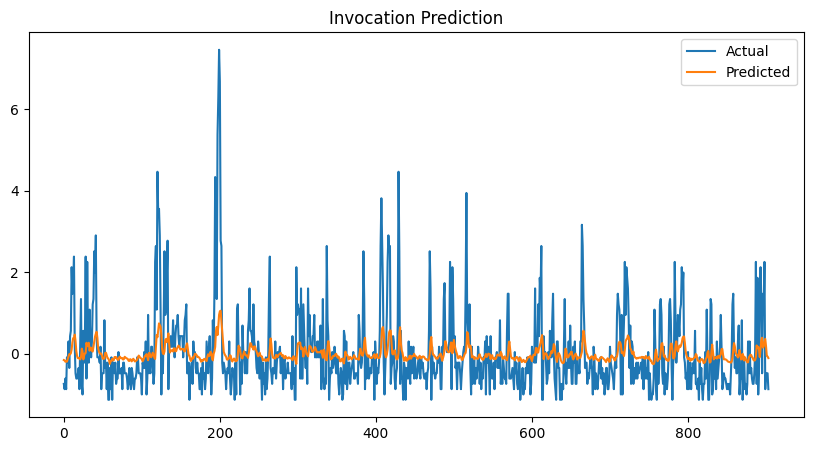

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Invocation Prediction")
plt.show()

### Visualization of Pre-Warming Strategy
We compare basic and load-aware pre-warming decisions.
This shows how adaptive strategies improve resource allocation.
It demonstrates the effectiveness of the proposed method.

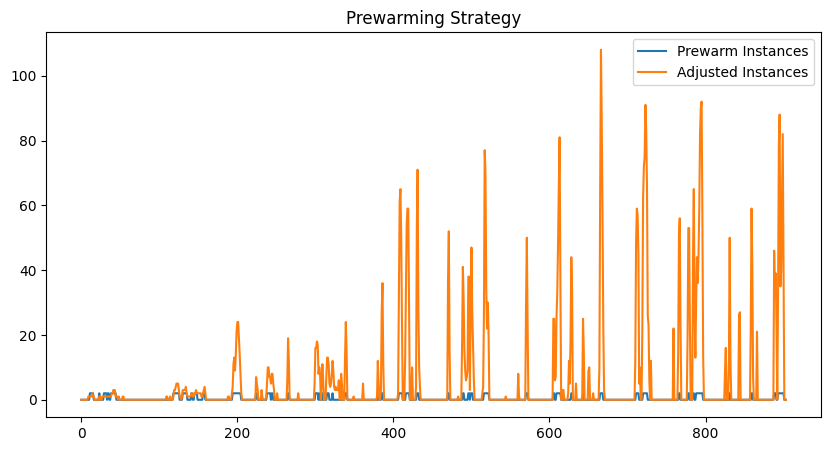

In [16]:
plt.figure(figsize=(10,5))
plt.plot(prewarm_list, label="Prewarm Instances")
plt.plot(adjusted_instances, label="Adjusted Instances")
plt.legend()
plt.title("Prewarming Strategy")
plt.show()

In [17]:
print("Sample Prewarm:", prewarm_list[:10])
print("Sample Capacity:", C_values[:10])

Sample Prewarm: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sample Capacity: [np.float64(1.906510980166771), np.float64(1.8167671825484293), np.float64(1.7730984628830722), np.float64(1.6665526706816531), np.float64(1.6938412364014517), np.float64(1.6518092842006862), np.float64(1.6920176801908677), np.float64(1.5993362333627092), np.float64(1.664253813709196), np.float64(1.7108550828220153)]


### Cold Start Simulation
We simulate cold starts when no pre-warmed instances are available.
This helps evaluate how effectively the system reduces latency.

In [18]:
cold_starts = [1 if w == 0 else 0 for w in prewarm_list]

print("Total Cold Starts:", sum(cold_starts))

Total Cold Starts: 738


### Baseline Comparison
We compare cold starts with and without pre-warming.
This shows the effectiveness of the proposed approach.

In [19]:
baseline_cold = len(pred)  # assume no prewarming

print("Baseline Cold Starts:", baseline_cold)
print("With Prewarming:", sum(cold_starts))

improvement = (baseline_cold - sum(cold_starts)) / baseline_cold * 100
print("Improvement (%):", improvement)

Baseline Cold Starts: 904
With Prewarming: 738
Improvement (%): 18.36283185840708


### CDF Analysis
We plot the cumulative distribution of cold starts.
This helps analyze how frequently cold starts occur.

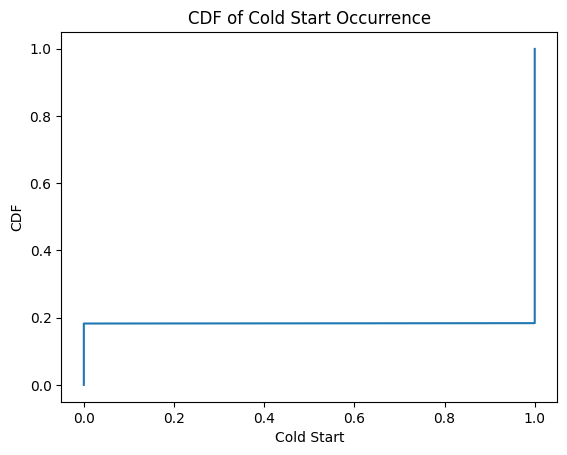

In [20]:
sorted_cs = np.sort(cold_starts)
cdf = np.arange(len(sorted_cs)) / len(sorted_cs)

plt.plot(sorted_cs, cdf)
plt.title("CDF of Cold Start Occurrence")
plt.xlabel("Cold Start")
plt.ylabel("CDF")
plt.show()